In [5]:
import pandas as pd, csv

path = "/Users/aaditya/VS Code/1000 genome project/Data/vcf_table.csv"

In [6]:
# --- Robust load: detect delimiter, keep header, clean names ---
with open(path, 'r', encoding='utf-8', errors='replace') as f:
    sample = ''.join([next(f) for _ in range(20)])
dialect = csv.Sniffer().sniff(sample, delimiters=[',','\t',';','|'])
sep = dialect.delimiter

df = pd.read_csv(path, sep=sep, header=0, low_memory=False)   # DO NOT use comment='#'
# normalize column names: strip spaces, drop BOM, upper for matching
df.columns = [c.strip().lstrip('\ufeff') for c in df.columns]

fixed = ['#CHROM','POS','ID','REF','ALT','QUAL','FILTER','INFO','FORMAT']
samples = [c for c in df.columns if c not in fixed and c not in ['CHROM']]  # some files use CHROM


In [7]:
# --- Safe QC: works even if FILTER column is missing or oddly cased ---
# find a FILTER-like column if present
filter_cols = [c for c in df.columns if c.strip().upper() == 'FILTER']
qual = pd.to_numeric(df.get('QUAL'), errors='coerce')

if filter_cols:
    fcol = filter_cols[0]
    df = df[(df[fcol].astype(str).str.upper() == 'PASS') & (qual > 30)].copy()
else:
    # proceed with QUAL only if FILTER column isn't present
    df = df[qual > 30].copy()

# keep only bi-allelic sites (ALT without commas)
df = df[~df['ALT'].astype(str).str.contains(',', na=False)].copy()

In [8]:
# convert genotypes to numeric {0,1,NaN}
G = df[samples].replace({'.': pd.NA, './.': pd.NA, '0|0':0, '1|1':1, '0/0':0, '1/1':1, '0':0, '1':1})
G = G.apply(pd.to_numeric, errors='coerce')

# detect putative males on chr-Y (≥5% calls)
male_mask = 1 - G.isna().mean() > 0.05
male_samples = list(male_mask[male_mask].index)
Gm = G[male_samples]


In [9]:
# per-variant metrics
var_call = 1 - Gm.isna().mean(axis=1)
var_af   = Gm.mean(axis=1, skipna=True)

variant_summary = pd.DataFrame({
    '#CHROM': df.get('#CHROM', df.get('CHROM')),
    'POS': df['POS'],
    'ID': df['ID'],
    'REF': df['REF'],
    'ALT': df['ALT'],
    'QUAL': qual.loc[df.index],
    'call_rate': var_call,
    'AF': var_af
})

print("Loaded with sep:", repr(sep))
print("Columns:", df.columns.tolist()[:20], "...")  # quick peek
print(f"Samples: {len(samples)} | Males detected: {len(male_samples)}")
print(variant_summary.head())

Loaded with sep: ','
Columns: ['#CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'FORMAT', 'HG00096', 'HG00101', 'HG00103', 'HG00105', 'HG00107', 'HG00108', 'HG00109', 'HG00112', 'HG00113', 'HG00114', 'HG00115'] ...
Samples: 1233 | Males detected: 1233
  #CHROM      POS          ID REF ALT  QUAL  call_rate        AF
0      Y  2655180  rs11575897   G   A   100        1.0  0.017843
1      Y  2655471           .   A   C   100        1.0  0.004055
2      Y  2655754           .   A   T   100        1.0  0.000811
3      Y  2655800           .   A   G   100        1.0  0.000811
4      Y  2655989           .   A   G   100        1.0  0.000811


In [10]:
# keep high-quality sites
vs = variant_summary.copy()
keep = (vs['call_rate'] >= 0.95) & (vs['QUAL'] >= 30)  # tweak thresholds as needed
clean_idx = keep[keep].index

Gm_clean = Gm.loc[clean_idx]
vs_clean = vs.loc[clean_idx].reset_index(drop=True)


In [11]:
vs_clean.to_csv("chrY_variant_summary_qc.csv", index=False)
pd.DataFrame({'sample': Gm_clean.columns,
              'missing_rate': Gm_clean.isna().mean().values,
              'alt_burden': Gm_clean.sum(min_count=1).values}
            ).to_csv("chrY_sample_summary_qc.csv", index=False)


Matplotlib is building the font cache; this may take a moment.


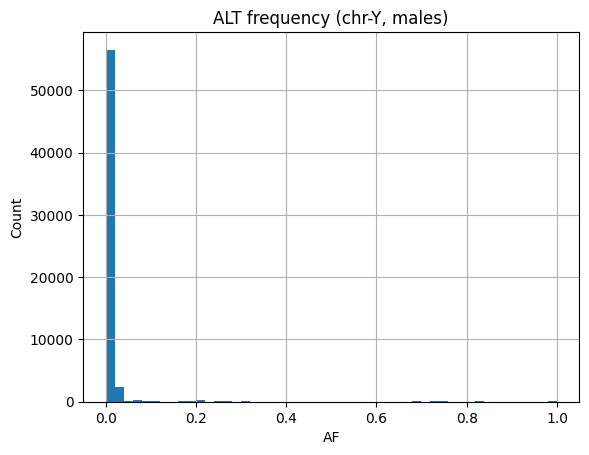

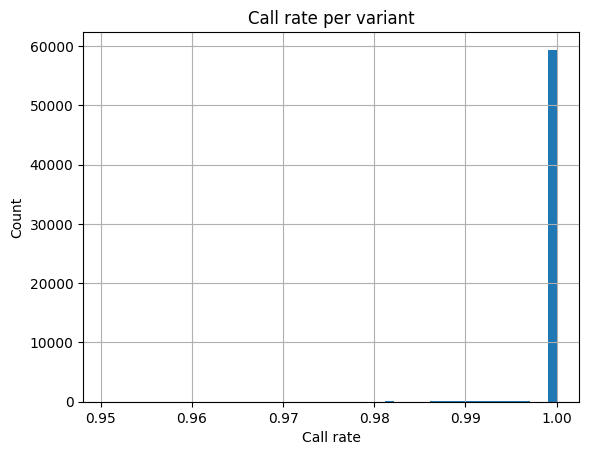

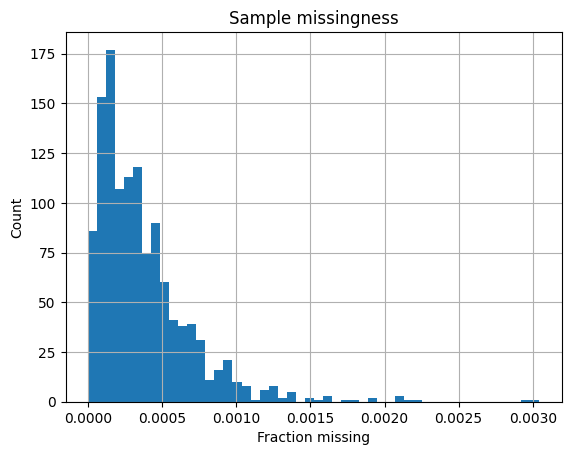

In [12]:
import matplotlib.pyplot as plt

vs_clean['AF'].hist(bins=50); plt.title("ALT frequency (chr-Y, males)"); plt.xlabel("AF"); plt.ylabel("Count"); plt.show()
vs_clean['call_rate'].hist(bins=50); plt.title("Call rate per variant"); plt.xlabel("Call rate"); plt.ylabel("Count"); plt.show()

sr = Gm_clean.isna().mean()
sr.hist(bins=50); plt.title("Sample missingness"); plt.xlabel("Fraction missing"); plt.ylabel("Count"); plt.show()


In [13]:
bad = sr[sr > 0.1].index  # e.g., >10% missing after QC
Gm_clean = Gm_clean.drop(columns=bad)


In [15]:
panel = pd.read_csv(
    r"/Users/aaditya/VS Code/1000 genome project/integrated_call_samples_v3.20130502.ALL.panel",
    sep="\t"
)
print(panel.head())






    sample  pop super_pop  gender  Unnamed: 4  Unnamed: 5
0  HG00096  GBR       EUR    male         NaN         NaN
1  HG00097  GBR       EUR  female         NaN         NaN
2  HG00099  GBR       EUR  female         NaN         NaN
3  HG00100  GBR       EUR  female         NaN         NaN
4  HG00101  GBR       EUR    male         NaN         NaN


In [16]:
panel = panel.rename(columns={'sample':'sample', 'super_pop':'POP'})
male_meta = panel[panel['sample'].isin(Gm_clean.columns)][['sample','POP']]
print(male_meta.value_counts('POP'))  # how many males per population

mat = Gm_clean.T.reset_index().rename(columns={'index':'sample'})
mat = mat.merge(male_meta, on='sample', how='left')

af_by_pop = {}
for pop, sub in mat.groupby('POP'):
    af_by_pop[pop] = sub.drop(columns=['sample','POP']).T.mean(axis=1, skipna=True).values

af_by_pop_df = pd.DataFrame(af_by_pop, index=vs_clean.index)
af_by_pop_df.to_csv("chrY_AF_by_population.csv", index=False)

POP
AFR    319
SAS    260
EAS    244
EUR    240
AMR    170
Name: count, dtype: int64


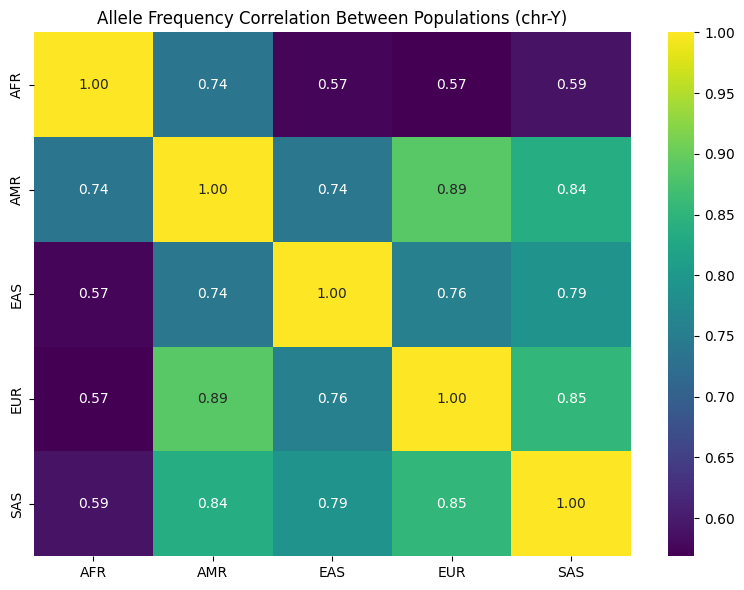

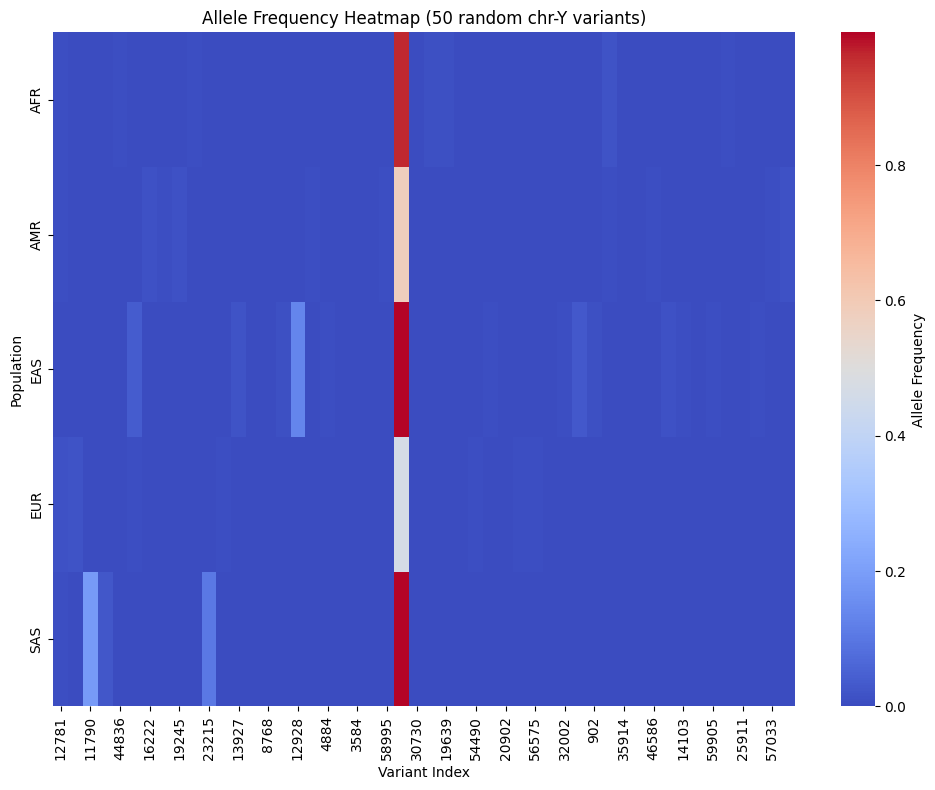

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the allele frequency data
df = pd.read_csv("chrY_AF_by_population.csv")

# Remove non-population columns if they exist
non_pop_cols = ['#CHROM', 'POS', 'ID', 'REF', 'ALT']
pop_cols = [c for c in df.columns if c not in non_pop_cols]

# --- 1️⃣  Correlation heatmap between populations ---
corr_matrix = df[pop_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis")
plt.title("Allele Frequency Correlation Between Populations (chr-Y)")
plt.tight_layout()
plt.show()

# --- 2️⃣  Optional: Variant vs Population heatmap ---
# If you want to see the allele frequency distribution of variants across populations
subset = df[pop_cols].sample(n=min(50, len(df)), random_state=42)  # 50 random variants for clarity
plt.figure(figsize=(10,8))
sns.heatmap(subset.T, cmap="coolwarm", cbar_kws={'label':'Allele Frequency'})
plt.xlabel("Variant Index")
plt.ylabel("Population")
plt.title("Allele Frequency Heatmap (50 random chr-Y variants)")
plt.tight_layout()
plt.show()
